In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn import svm
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score

In [3]:
# ID: ID Number of Customers.
# Warehouse block: The Company have big Warehouse which is divided in to block such as A,B,C,D,E.
# Mode of shipment:The Company Ships the products in multiple way such as Ship, Flight and Road.
# Customer care calls: The number of calls made from enquiry for enquiry of the shipment.
# Customer rating: The company has rated from every customer. 1 is the lowest (Worst), 5 is the highest (Best).
# Cost of the product: Cost of the Product in US Dollars.
# Prior purchases: The Number of Prior Purchase.
# Product importance: The company has categorized the product in the various parameter such as low, medium, high.
# Gender: Male and Female.
# Discount offered: Discount offered on that specific product.
# Weight in gms: It is the weight in grams.
# Reached on time: It is the target variable, where 1 Indicates that the product has NOT reached on time and 0 indicates it has reached on time.
df = pd.read_csv('datasets/shipping.csv')
df.head(15)

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1
5,6,F,Flight,3,1,162,3,medium,F,12,1417,1
6,7,D,Flight,3,4,250,3,low,F,3,2371,1
7,8,F,Flight,4,1,233,2,low,F,48,2804,1
8,9,A,Flight,3,4,150,3,low,F,11,1861,1
9,10,B,Flight,3,2,164,3,medium,F,29,1187,1


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   10999 non-null  int64 
 1   Warehouse_block      10999 non-null  object
 2   Mode_of_Shipment     10999 non-null  object
 3   Customer_care_calls  10999 non-null  int64 
 4   Customer_rating      10999 non-null  int64 
 5   Cost_of_the_Product  10999 non-null  int64 
 6   Prior_purchases      10999 non-null  int64 
 7   Product_importance   10999 non-null  object
 8   Gender               10999 non-null  object
 9   Discount_offered     10999 non-null  int64 
 10  Weight_in_gms        10999 non-null  int64 
 11  Reached.on.Time_Y.N  10999 non-null  int64 
dtypes: int64(8), object(4)
memory usage: 1.0+ MB


In [8]:
df.describe()

,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
count,10999.00000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000
mean,5500.00000,4.054459,2.990545,210.196836,3.567597,13.373216,3634.016729,0.596691
std,3175.28214,1.141490,1.413603,48.063272,1.522860,16.205527,1635.377251,0.490584
min,1.00000,2.000000,1.000000,96.000000,2.000000,1.000000,1001.000000,0.000000
25%,2750.50000,3.000000,2.000000,169.000000,3.000000,4.000000,1839.500000,0.000000
50%,5500.00000,4.000000,3.000000,214.000000,3.000000,7.000000,4149.000000,1.000000
75%,8249.50000,5.000000,4.000000,251.000000,4.000000,10.000000,5050.000000,1.000000
max,10999.00000,7.000000,5.000000,310.000000,10.000000,65.000000,7846.000000,1.000000


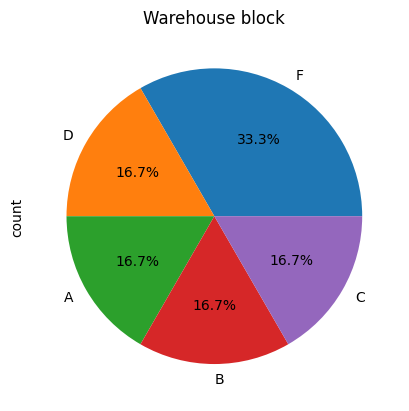

In [27]:
plt.title('Warehouse block')
wh_block_values = df['Warehouse_block'].value_counts()
wh_block_values.plot.pie(autopct='%1.1f%%')
plt.show()

#F block is most popular for storing products

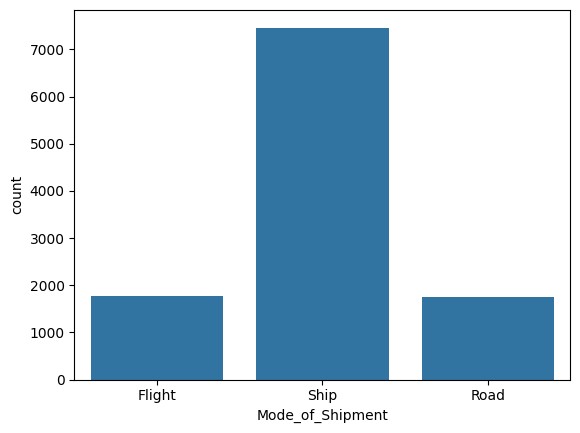

In [31]:
plt.figure()
sns.countplot(df, x='Mode_of_Shipment')
plt.show()

# Ship - is the most popular variant of transporting

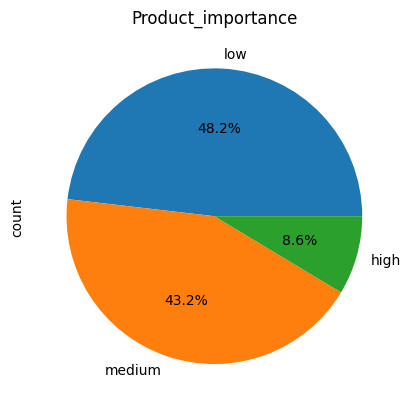

In [39]:
plt.title('Product_importance')
df['Product_importance'].value_counts().plot.pie(autopct="%1.1f%%")
plt.show()

# high important products are shipping rerely that other categories

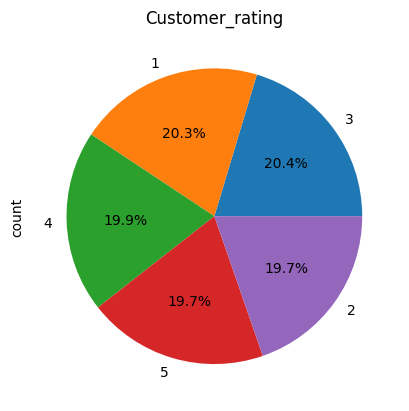

In [41]:
plt.title('Customer_rating')
df['Customer_rating'].value_counts().plot.pie(autopct="%1.1f%%")
plt.show()

# Count of each rating is 20%

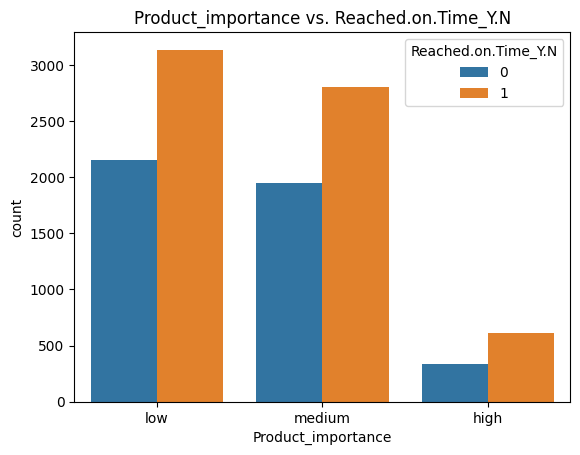

In [44]:
plt.figure()
plt.title('Product_importance vs. Reached.on.Time_Y.N')
sns.countplot(x = 'Product_importance', hue = 'Reached.on.Time_Y.N', data = df)
plt.show()

# company ship all categroies of products, no seen on their importance

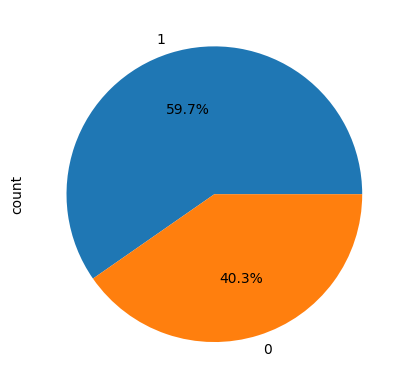

In [4]:
df['Reached.on.Time_Y.N'].value_counts().plot.pie(autopct="%1.1f%%")
plt.show()

# Most of products are reached on time

In [7]:
df1=df.copy()
df1=pd.get_dummies(df1,columns=['Mode_of_Shipment','Product_importance','Gender'],drop_first=True)
df1

,ID,Warehouse_block,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N,Mode_of_Shipment_Road,Mode_of_Shipment_Ship,Product_importance_low,Product_importance_medium,Gender_M
0,1,D,4,2,177,3,44,1233,1,False,False,True,False,False
1,2,F,4,5,216,2,59,3088,1,False,False,True,False,True
2,3,A,2,2,183,4,48,3374,1,False,False,True,False,True
3,4,B,3,3,176,4,10,1177,1,False,False,False,True,True
4,5,C,2,2,184,3,46,2484,1,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10994,10995,A,4,1,252,5,1,1538,1,False,True,False,True,False
10995,10996,B,4,1,232,5,6,1247,0,False,True,False,True,False
10996,10997,C,5,4,242,5,4,1155,0,False,True,True,False,False
10997,10998,F,5,2,223,6,2,1210,0,False,True,False,True,True


In [9]:
from sklearn.calibration import LabelEncoder


enc = LabelEncoder()
df1['Warehouse_block']=enc.fit_transform(df1['Warehouse_block'])
df1

,ID,Warehouse_block,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N,Mode_of_Shipment_Road,Mode_of_Shipment_Ship,Product_importance_low,Product_importance_medium,Gender_M
0,1,3,4,2,177,3,44,1233,1,False,False,True,False,False
1,2,4,4,5,216,2,59,3088,1,False,False,True,False,True
2,3,0,2,2,183,4,48,3374,1,False,False,True,False,True
3,4,1,3,3,176,4,10,1177,1,False,False,False,True,True
4,5,2,2,2,184,3,46,2484,1,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10994,10995,0,4,1,252,5,1,1538,1,False,True,False,True,False
10995,10996,1,4,1,232,5,6,1247,0,False,True,False,True,False
10996,10997,2,5,4,242,5,4,1155,0,False,True,True,False,False
10997,10998,4,5,2,223,6,2,1210,0,False,True,False,True,True


In [12]:
# Prepare dataset for fitting 

x = df1.drop(['Reached.on.Time_Y.N','ID'], axis=1)
x

,Warehouse_block,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Mode_of_Shipment_Road,Mode_of_Shipment_Ship,Product_importance_low,Product_importance_medium,Gender_M
0,3,4,2,177,3,44,1233,False,False,True,False,False
1,4,4,5,216,2,59,3088,False,False,True,False,True
2,0,2,2,183,4,48,3374,False,False,True,False,True
3,1,3,3,176,4,10,1177,False,False,False,True,True
4,2,2,2,184,3,46,2484,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
10994,0,4,1,252,5,1,1538,False,True,False,True,False
10995,1,4,1,232,5,6,1247,False,True,False,True,False
10996,2,5,4,242,5,4,1155,False,True,True,False,False
10997,4,5,2,223,6,2,1210,False,True,False,True,True


In [14]:
# target
y = df1['Reached.on.Time_Y.N']

In [17]:
x_train,x_test,y_train,y_test=train_test_split(x, y, test_size=0.2,random_state=42)


In [22]:
# Logistic regression
logistic_reg = LogisticRegression()

logistic_reg.fit(x_train, y_train)

c:\Users\Acer\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [20]:
y_pred = logistic_reg.predict(x_test)
y_pred

array([1, 0, 0, ..., 1, 0, 0], dtype=int64)

In [21]:
y_test = np.array(y_test)
y_test

array([1, 1, 0, ..., 1, 1, 0], dtype=int64)

In [27]:
#accuracy

acc = accuracy_score(y_test, y_pred)
print(acc)

0.6377272727272727


In [28]:
# F1 score
f1 = f1_score(y_test, y_pred)
print(f1)

0.6914440572977159


In [29]:
# SVM
sv_machine = svm.SVC(kernel='linear')

sv_machine.fit(x_train, y_train)

y_pred = sv_machine.predict(x_test)
y_pred

array([1, 0, 0, ..., 1, 0, 0], dtype=int64)

In [30]:
#accuracy

acc = accuracy_score(y_test, y_pred)
print(acc)

0.649090909090909


In [31]:
f1 = f1_score(y_test, y_pred)
print(f1)

0.6660899653979239


In [45]:
# Decision tree

des_tree = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)
des_tree.fit(x_train, y_train)

y_pred_dt = des_tree.predict(x_test)
y_pred_dt

array([1, 0, 0, ..., 0, 1, 0], dtype=int64)

In [46]:
acc = accuracy_score(y_test, y_pred_dt)
print(acc)

0.6863636363636364


In [47]:
f1 = f1_score(y_test, y_pred_dt)
print(f1)

0.6634146341463415


In [53]:
# Random forest
rand_forest = RandomForestClassifier(n_estimators=100,random_state=42)
rand_forest.fit(x_train,y_train)

y_pred_rf = rand_forest.predict(x_test)
y_pred_rf

array([1, 0, 1, ..., 0, 1, 0], dtype=int64)

In [54]:
acc = accuracy_score(y_test, y_pred_rf)
print(acc)

0.67


In [55]:
f1 = f1_score(y_test, y_pred_rf)
print(f1)

0.7


In [56]:
# XGBClassifier

xgb = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
xgb.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [57]:
y_pred_xg = xgb.predict(x_test)
y_pred_xg

array([1, 0, 1, ..., 0, 0, 0])

In [58]:
acc = accuracy_score(y_test, y_pred_xg)
print(acc)

0.675


In [59]:
f1 = f1_score(y_test, y_pred_xg)
print(f1)

0.6932646932646933


In [ ]:
# Prediction results are almost equal on different models fitting, bu in fact the best value of loss was on Random Forest model